In [ ]:
import os
import polars as pl
from processing.ecc import ECC, SHADOZ
%matplotlib widget

In [ ]:
# choose a file
file = 'tests/data/ecc_asap/20220504C37105.TXT'

# Create an instance of the ECCSONDE class
sonde = ECC()

# Use the extract_ecc_asap method to process the file
result = sonde.extract_ecc_asap(file=file)

# Plot the result
sonde.plot_ecc_asap(result, suptitle=file)

In [ ]:
# select folder with ECC ASAP data
folder_path = '/product_data/data/pay/Kenya/NRB/OZONE_ECC_ASAP/incoming/'

for year in range(2019, 2025):
    year = str(year)
    # Compile data and metadata from the specified folder
    compiled_data = sonde.compile_ecc_asap(folder_path=os.path.join(folder_path, year))

    # Access the compiled metadata and data
    metadata_df = compiled_data['metadata']
    metadata_df.write_parquet(f'data/level1/ecc_asap_metadata_{year}.parquet')
    data_df = compiled_data['data']
    data_df.write_parquet(f'data/level1/ecc_asap_data_{year}.parquet')

In [ ]:
import polars as pl
for year in range(2019, 2025):
    year = str(year)
    data_df = pl.read_parquet(f'data/level1/ecc/ecc_asap_data_{year}.parquet')

    # Plot the compiled data interactively
    path = os.path.join('results/ecc/', year)
    os.makedirs(path, exist_ok=True)

    sonde.plot_compiled_ecc_asap(data_df=data_df, suptitle=f'ECC ASAP {year}', interactive=False, path=path)

In [ ]:
shadoz = SHADOZ()
target = 'data/level1/ecc/shadoz'

for year in range(1998, 2023):
    df_data, df_metadata = shadoz.download_and_extract_shadoz_zip(year=year, target=target)

In [ ]:
# example
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from processing.ecc import ECC
from toolbox.numerical_analysis_1d import interpolate_logarithmic
import datetime

ecc = ECC()

df = pl.DataFrame()
for year in range(2003, 2025):
    try:
        # read SHADOZ data
        df_shadoz_year = pl.read_parquet(f'data/level1/ecc/shadoz/ecc_sonde_data_{year}.parquet')

        # read CAMS profile data
        df_cams_year = pl.read_parquet(f'data/level3/copernicus/cams/eac4/cams-global-reanalysis-eac4-monthly_{year}.parquet')

        # extract launch dates
        dtm_launches = df_shadoz_year.select(pl.col('dtm')).unique().to_series().to_list()

        for dtm in dtm_launches:
            try:
                # extract data
                df_shadoz = df_shadoz_year.filter(pl.col('dtm')==dtm)

                # collect relevant metadata
                filename = df_shadoz['filename'][0]
                burst_pressure = min(df_shadoz['Press'])
                tco_shadoz = max(df_shadoz['O3_DU'])

                # re-calculate total column ozone in Dobson units
                df_shadoz = ecc.total_column_ozone_from_pressure_profile(df=df_shadoz, pressure_col='Press', ozone_col='O3_mPa')
                # tco_ecc.write_csv('data/level1/ecc/shadoz/test.csv')
                tco_shadoz_recalc = max(df_shadoz['O3_DU_calc'])

                # select corresponding CAMS profile
                df_cams = df_cams_year.filter(pl.col('dte')==datetime.date(dtm.year, dtm.month, 1))
                # print(df_cams.schema)

                # interpolate CAMS profile
                df_cams = interpolate_logarithmic(df_cams['level'], df_cams['O3_mPa'], N=5, x0=burst_pressure)
                df_cams = df_cams.rename({'x': 'Press', 'y': 'O3_mPa'}).filter(pl.col('Press') <= burst_pressure)
                df_cams = ecc.total_column_ozone_from_pressure_profile(df=df_cams, pressure_col='Press', ozone_col='O3_mPa')
                residual_tco_cams = max(df_cams['O3_DU_calc'])

                tco_shadoz_cams = tco_shadoz + residual_tco_cams
                tco_shadoz_recalc_cams = tco_shadoz_recalc + residual_tco_cams
                _df = pl.DataFrame({'filename': filename,
                                    'dte': dtm.strftime('%Y-%m-%d'),
                                    'burst_pressure_hPa': burst_pressure,
                                    'tco_shadoz': tco_shadoz,
                                    'tco_shadoz_recalc': tco_shadoz_recalc,
                                    'tco_shadoz_cams': tco_shadoz_cams,
                                    'tco_shadoz_recalc_cams': tco_shadoz_recalc_cams,
                                    })
            except Exception as err:
                print(f"year={year}: {err}")
                pass

            df = pl.concat([df, _df], how='diagonal')
        
    except Exception as err:
        print(f"year={year}: {err}")
        pass

display(df)

In [ ]:
df = df.sort(by='dte')
fig = plt.figure(figsize=(10, 6))
plt.scatter(df['dte'].str.to_date(), df['tco_shadoz'], s=6, label="TCO from SHADOZ file until burst")
# plt.scatter(df['dte'].str.to_date(), df['tco_shadoz_recalc'], marker='o', c='red', s=8, label="TCO from SHADOZ file until burst (recalculated)")
plt.scatter(df['dte'].str.to_date(), df['tco_shadoz_cams'], marker='o', c='red', s=12, label="TCO from SHADOZ file until burst + residual from CAMS")
# plt.scatter(df['dte'].str.to_date(), df['tco_shadoz_recalc_cams'], marker='o', c='orange', s=8, label="TCO from SHADOZ file until burst (recalculated) + residual from CAMS")
plt.xlim(datetime.date(2000,1,1), datetime.date(2024,1,1))
plt.ylim(220, 280)
plt.xlabel('Date')
plt.ylabel('Total column ozone [DU]')
# plt.suptitle(suptitle)
plt.title('Total Column Ozone from Nairobi ECC ozone soundings')
# plt.grid(True)
plt.legend()
plt.show()
df.write_csv('results/ecc/tco_from_ecc.csv')
fig.savefig('results/ecc/tco_from_ecc.png')

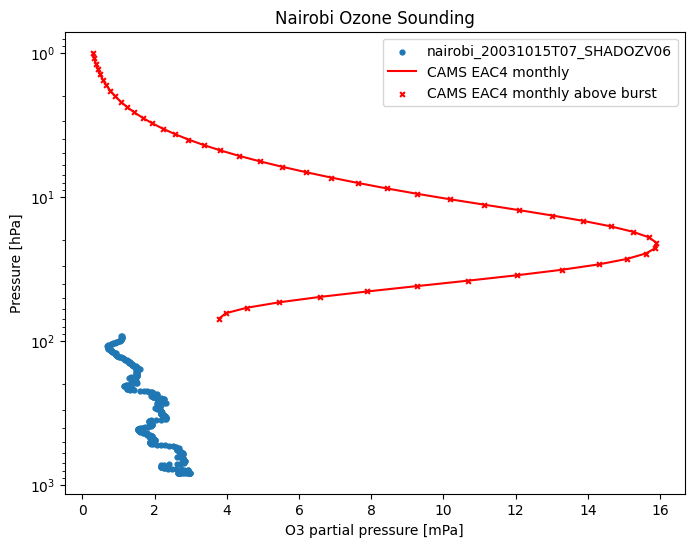

index 0 is out of bounds for sequence of length 0


KeyboardInterrupt: 

In [6]:
import datetime
import matplotlib.pyplot as plt
import polars as pl
from processing.ecc import ECC
ecc = ECC()

for year in range(2003, 2024):
    try:
        df_ecc_year = pl.read_parquet(f'data/level1/ecc/shadoz/ecc_sonde_data_{year}.parquet')

        # extract launch date
        dtm_launches = df_ecc_year.select(pl.col('dtm')).unique().to_series().to_list()

        for dtm_launch in dtm_launches:
            df_ecc = df_ecc_year.filter(pl.col('dtm')==dtm_launch)
            df_model_year = pl.read_parquet(f'data/level3/copernicus/cams/eac4/cams-global-reanalysis-eac4-monthly_{year}.parquet')
            df_model_year = df_model_year.rename({'level': 'Press'})
            df_model = df_model_year.filter(pl.col('dte')==datetime.date(dtm_launch.year, dtm_launch.month, 1))

            ecc.plot_ecc_profile(df_ecc=df_ecc, df_model=df_model, model='CAMS EAC4 monthly', title='Nairobi Ozone Sounding')
    except Exception as err:
        print(err)
        pass

In [ ]:
import datetime as datetime
import polars as pl


# Identify the corresponding CAMS profile from the monthly reanalysis
df_cams = pl.read_parquet('data/level3/copernicus/cams/eac4/cams-global-reanalysis-eac4-monthly_2020.parquet')
df_cams_month = df_cams.filter(pl.col('dte')==datetime.date(2020, 2, 1))
print(df_cams.schema)


df_cams_interpolated = interpolate_logarithmic(df_cams_month['level'], df_cams_month['O3_mPa'], N=5, x0=burst_pressure)
df_cams_interpolated = df_cams_interpolated.rename({'x': 'Press', 'y': 'O3_mPa'}).filter(pl.col('Press') <= burst_pressure)
df_cams_calc = ecc.total_column_ozone_from_pressure_profile(df=df_cams_interpolated, pressure_col='Press', ozone_col='O3_mPa')
residual_tco_cams_calc = max(df_cams_calc['O3_DU_calc'])

tco_shadoz_cams = tco_shadoz + residual_tco_cams_calc
tco_calc_cams = tco_ecc_calc + residual_tco_cams_calc

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 5))
plt.scatter(df_ecc['O3_mPa']*10, df_ecc['Press'], s=8, c="b", label='ECC sonde')
plt.scatter(df_cams_month['O3_mPa']*10, df_cams_month['level'], c='red', label='CAMS reanalysis')
plt.plot(df_cams_interpolated['O3_mPa']*10, df_cams_interpolated['Press'], c='red')
plt.yscale('log')
plt.xlabel('O3 [nbar]')
plt.ylabel('Pressure [hPa]')
plt.title(df_ecc['filename'][0])
plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [ ]:
# compute residual profile from CAMS reanalysis
burst_pressure = min(df_ecc['Press'])

df_cams_interpolated_residual = df_cams_interpolated.filter(pl.col('Press') <= burst_pressure)
print(df_cams_interpolated_residual)
# Compute the total column ozone in DU
# tco_residual = compute_total_column_ozone_from_insitu_profile(df_cams_interpolated_residual['Press'], df_cams_interpolated_residual['O3_mPa'])
# print(tco_residual)